In [1]:
import pandas as pd


In [11]:
import pandas as pd
import yfinance as yf

# Pick your tickers — change these to whatever you want to track
tickers = ["AAPL", "MSFT", "VOO", "NVDA"]

# Download ~4 years of daily data
data = yf.download(tickers, start="2021-01-01", end="2025-01-01")

# Keep just the closing prices
prices = data["Close"]

# Look at what we got
print(prices.shape)   # (rows, columns) — should be ~1000 rows, 4 columns
prices.head()         # first few rows

[*********************100%***********************]  4 of 4 completed

(1005, 4)


Ticker,AAPL,MSFT,NVDA,VOO
Date,,,,
2021-01-04,125.740852,207.956131,13.076018,314.577942
2021-01-05,127.295464,208.156738,13.366435,316.647125
2021-01-06,123.010521,202.759369,12.578444,318.567841
2021-01-07,127.208031,208.529282,13.305859,323.327850
2021-01-08,128.305984,209.799835,13.238800,325.146393


In [3]:
prices.head()

Ticker,AAPL,MSFT,NVDA,VOO
Date,,,,
2021-01-04,125.740852,207.956131,13.076018,314.577942
2021-01-05,127.295464,208.156738,13.366435,316.647125
2021-01-06,123.010521,202.759369,12.578444,318.567841
2021-01-07,127.208031,208.529282,13.305859,323.327850
2021-01-08,128.305984,209.799835,13.238800,325.146393


<Axes: xlabel='Date'>

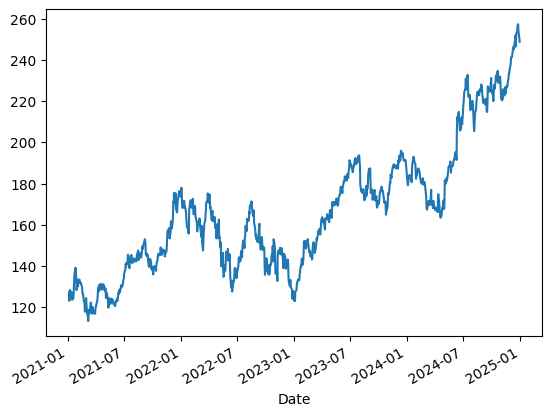

In [4]:
prices.tail()        # last 5 rows — confirms data runs to end of 2024
prices.describe()    # min/max/mean per stock — quick overview
prices["AAPL"].plot()  # your first chart — just AAPL's price over time

In [5]:
# Daily returns: % change from one day to the next
daily_returns = prices.pct_change()

daily_returns.head()   # first row is NaN — there's no "day before" day 1

Ticker,AAPL,MSFT,NVDA,VOO
Date,,,,
2021-01-04,NaN,NaN,NaN,NaN
2021-01-05,0.012364,0.000965,0.022210,0.006578
2021-01-06,-0.033661,-0.025929,-0.058953,0.006066
2021-01-07,0.034123,0.028457,0.057830,0.014942
2021-01-08,0.008631,0.006093,-0.005040,0.005624


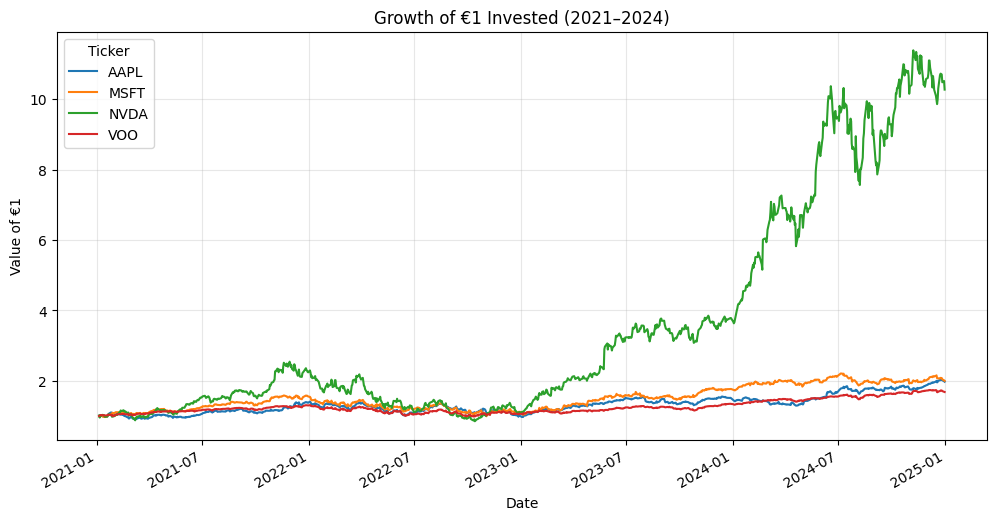

In [6]:
import matplotlib.pyplot as plt

# Cumulative growth: what €1 invested on day 1 would be worth over time
cumulative = (1 + daily_returns).cumprod()

# Plot all four holdings on one chart
cumulative.plot(figsize=(12, 6))
plt.title("Growth of €1 Invested (2021–2024)")
plt.ylabel("Value of €1")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import numpy as np

# Annualised volatility = std dev of daily returns × √252
# (252 = roughly the number of trading days in a year)
volatility = daily_returns.std() * np.sqrt(252)

# Show as a sorted % — highest risk first
(volatility * 100).sort_values(ascending=False).round(2)

Ticker
NVDA    52.87
AAPL    26.60
MSFT    26.07
VOO     16.44
dtype: float64

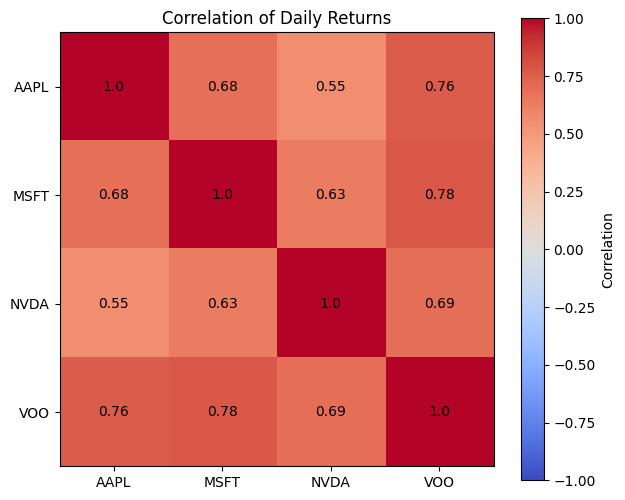

In [8]:
import matplotlib.pyplot as plt

# Correlation matrix: how closely holdings move together (-1 to +1)
corr = daily_returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Label the axes with ticker names
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)

# Write the number in each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

plt.colorbar(im, label="Correlation")
plt.title("Correlation of Daily Returns")
plt.show()

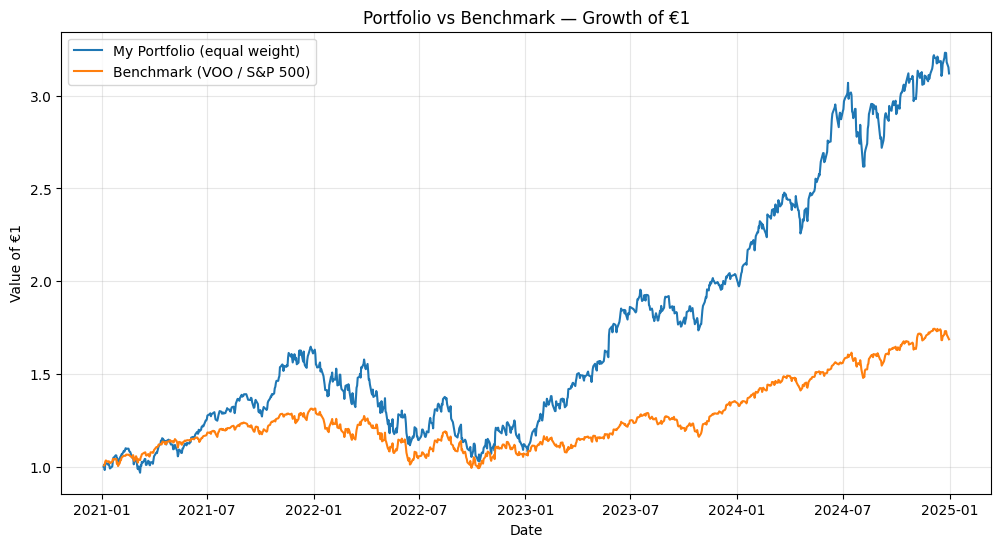

In [9]:
# Equal-weight portfolio: split evenly across the 4 holdings
weights = pd.Series(0.25, index=daily_returns.columns)

# Portfolio's daily return = weighted average of each holding's daily return
portfolio_daily = (daily_returns * weights).sum(axis=1)

# Use VOO as the benchmark (the S&P 500)
benchmark_daily = daily_returns["VOO"]

# Cumulative growth of €1 for portfolio vs benchmark
portfolio_cum = (1 + portfolio_daily).cumprod()
benchmark_cum = (1 + benchmark_daily).cumprod()

# Plot them together
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum, label="My Portfolio (equal weight)")
plt.plot(benchmark_cum, label="Benchmark (VOO / S&P 500)")
plt.title("Portfolio vs Benchmark — Growth of €1")
plt.ylabel("Value of €1")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
risk_free_rate = 0.04   # ~4% annual, rough current level

# Annualised return and volatility for portfolio and benchmark
def annual_stats(daily):
    ann_return = daily.mean() * 252
    ann_vol = daily.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    return ann_return, ann_vol, sharpe

for name, series in [("Portfolio", portfolio_daily), ("Benchmark (VOO)", benchmark_daily)]:
    ann_return, ann_vol, sharpe = annual_stats(series)
    print(f"{name}:")
    print(f"  Annual return:     {ann_return*100:.1f}%")
    print(f"  Annual volatility: {ann_vol*100:.1f}%")
    print(f"  Sharpe ratio:      {sharpe:.2f}")
    print()

Portfolio:
  Annual return:     32.0%
  Annual volatility: 26.5%
  Sharpe ratio:      1.06

Benchmark (VOO):
  Annual return:     14.5%
  Annual volatility: 16.4%
  Sharpe ratio:      0.64

